# EN3160 Assignment 01 #
**Intensity Transformations and Neighborhood Filtering**

**Name:** Dilhara D.S.  

**Index Number:** 230147L 

**GitHub:** [repo link](https://github.com/sachi1645/Intensity-Transformations-and-Neighborhood-Filtering)


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
def plt_1(a, b, x, y, xlabel, ylabel, title):
    plt.figure(figsize=(a, b)), plt.plot(x, y, '-o', markersize=3)
    plt.xlabel(xlabel), plt.ylabel(ylabel), plt.title(title)
    plt.grid(True), plt.tight_layout(), plt.show()

def plt_2(a, b, c, im, title, cmap=None):
    plt.subplot(a, b, c), plt.imshow(im, cmap=cmap)
    plt.title(title), plt.axis("off")
    
def plt_3(a, b, c, x, y=None, xlabel='', ylabel='', title='', kind='plot', bins=256, range_=None):
    plt.subplot(a, b, c)
    if kind == 'hist': plt.hist(np.asarray(x).ravel(), bins=bins, range=range_)
    else:plt.plot(x, y, '-o', markersize=3)
    plt.xlabel(xlabel), plt.ylabel(ylabel)
    plt.title(title), plt.grid(True)

# Question 1 — Intensity Transformation

In [ ]:
def intensity_transformation(im, breakpoints):
    im_float = im.astype(np.float32)
    bp = np.asarray(breakpoints, dtype=np.float32)
    output = np.zeros_like(im_float)
    for i in range(len(bp) - 1):
        x1, y1 = bp[i]
        x2, y2 = bp[i + 1]
        if x2 == x1: continue
        if i == len(bp) - 2: mask = (im_float >= x1) & (im_float <= x2)
        else: mask = (im_float >= x1) & (im_float < x2)
        output[mask] = ((y2 - y1) / (x2 - x1)) * (im_float[mask] - x1) + y1
    return np.clip(output, 0, 255).astype(np.uint8)

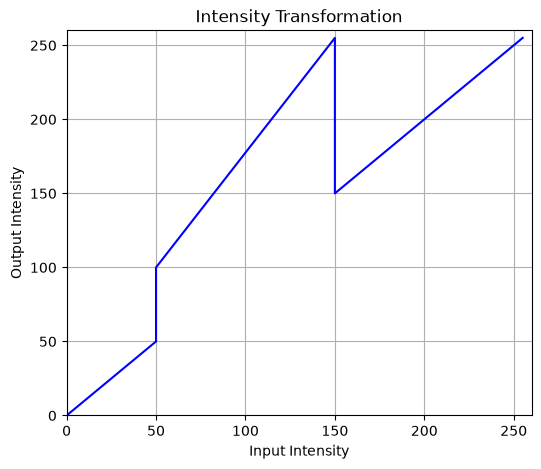

In [ ]:
im1 = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150, 150), (255, 255)]
result1 = intensity_transformation(im1, breakpoints)
x, y = [p[0] for p in breakpoints], [p[1] for p in breakpoints]
plt_1(6, 4, x, y, 'Input Intensity', 'Output Intensity', 'Intensity Transformation')

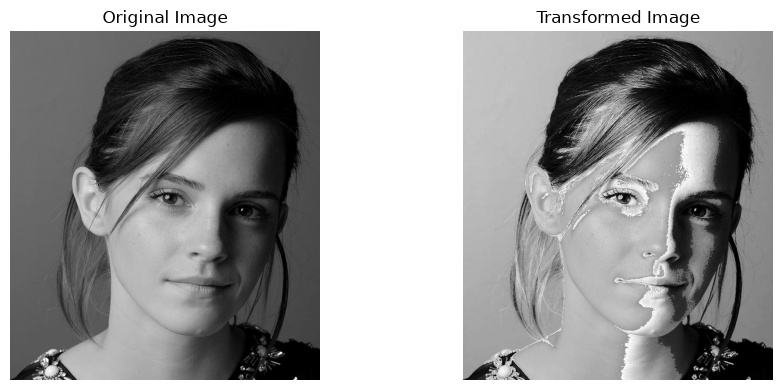

(None, None)

In [ ]:
plt.figure(figsize=(6, 4))
plt_2(1, 2, 1, im1, 'Original Image', 'gray')
plt_2(1, 2, 2, result1, 'Transformed Image', 'gray')
plt.tight_layout()
plt.show()

# Question 2 — White Matter and Gray Matter Enhancement

In [ ]:
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)
white_breakpoints = [(0, 0), (80, 20), (120, 255), (255, 255)]
white_result = intensity_transformation(brain, white_breakpoints)
gray_breakpoints = [(0, 0), (70, 1), (100, 255), (150, 255), (255, 255)]
gray_result = intensity_transformation(brain, gray_breakpoints)

x_1, y_1 = [p[0] for p in white_breakpoints], [p[1] for p in white_breakpoints]
x_2, y_2 = [p[0] for p in gray_breakpoints], [p[1] for p in gray_breakpoints]
plt.figure(figsize=(8, 4))
plt_3(1, 2, 1, x_1, y_1, 'Input Intensity', 'Output Intensity', 'White Matter Transformation')
plt_3(1, 2, 2, x_2, y_2, 'Input Intensity', 'Output Intensity', 'Gray Matter Transformation')
plt.tight_layout(), plt.show()

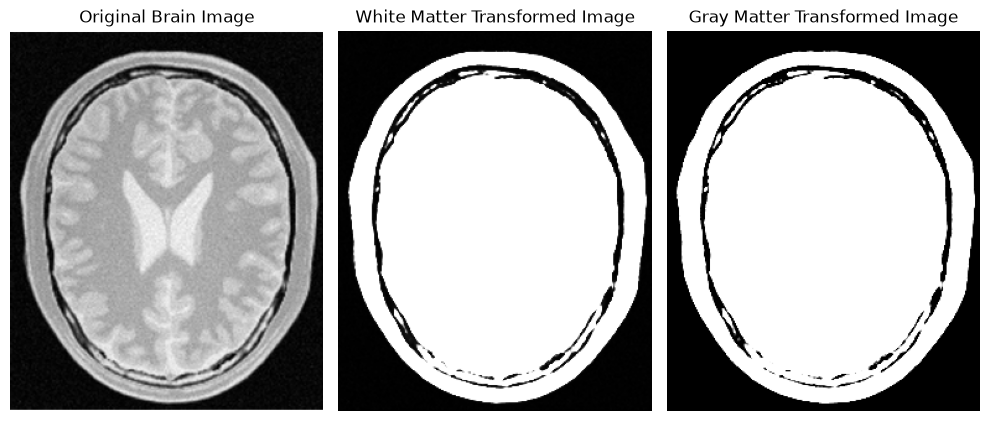

(None, None)

In [ ]:
plt.figure(figsize=(6, 4))
plt_2(1, 3, 1, brain, 'Original Brain Image', 'gray')
plt_2(1, 3, 2, white_result, 'White Matter Image', 'gray')
plt_2(1, 3, 3, gray_result, 'Gray Matter Image', 'gray')
plt.tight_layout(), plt.show()

# Question 3 — Gamma Correction

In [ ]:
img3 = cv.imread('images/3.webp')
lab = cv.cvtColor(img3, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)
gamma = 0.7
L_normalized  = L.astype(np.float32) / 255.0
L_gamma_corrected = np.power(L_normalized, gamma)
L_corrected = np.clip(L_gamma_corrected * 255, 0, 255).astype(np.uint8)
lab_corrected = cv.merge((L_corrected, a, b))
img3_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

plt.figure(figsize=(6, 4))
plt_2(1, 2, 1, cv.cvtColor(img3, cv.COLOR_BGR2RGB), 'Original Image')
plt_2(1, 2, 2, cv.cvtColor(img3_corrected, cv.COLOR_BGR2RGB), f'Gamma Corrected Image (γ = {gamma})')
plt.tight_layout(), plt.show()

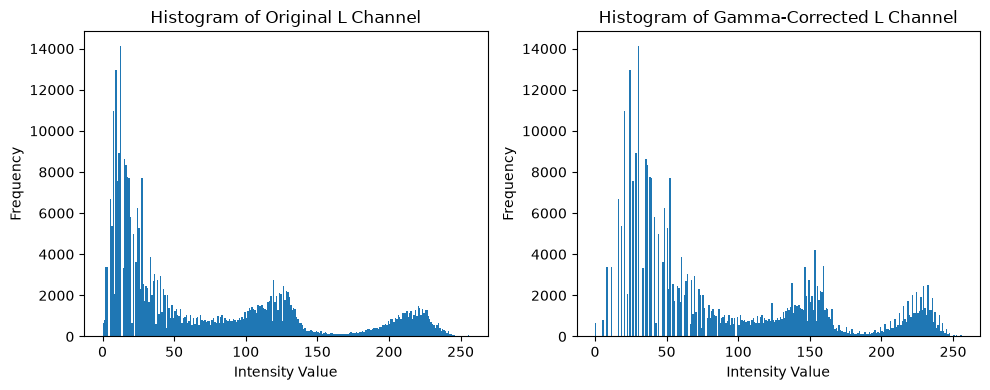

In [ ]:
plt.figure(figsize=(8, 4))
plt_3(1, 2, 1, L, None, 'Intensity Value', 'Frequency', 'Histogram of Original L Channel', kind='hist', bins=256, range_=(0, 256))
plt_3(1, 2, 2, L_corrected, None, 'Intensity Value', 'Frequency', 'Histogram of Gamma-Corrected L Channel', kind='hist', bins=256, range_=(0, 256))
plt.tight_layout(), plt.show()

A gamma value smaller than 1 brightens darker intensity values more
strongly than brighter values. In this experiment, γ = 0.7 was used as
a starting value.The corrected L histogram is shifted toward higher intensity values,
indicating that darker regions have become brighter.



# Question 4 — Vibrance Enhancement

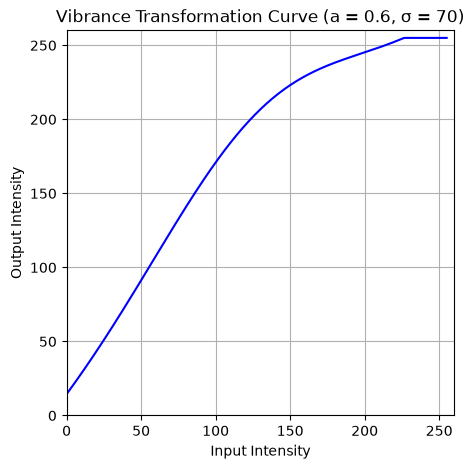

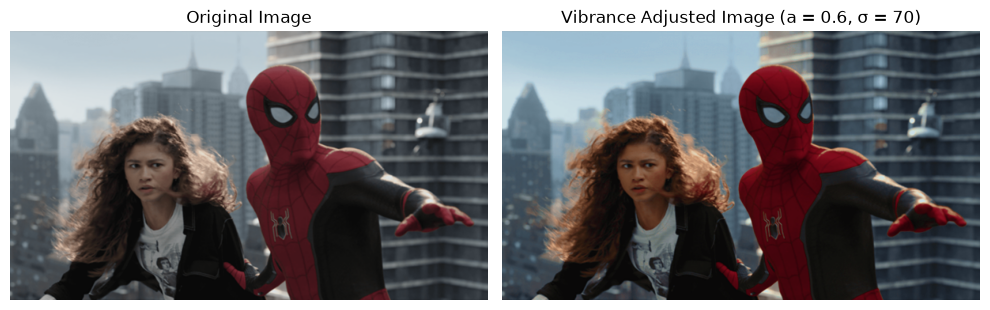

(None, None)

In [ ]:
img4 = cv.imread('images/4.png')
hsv = cv.cvtColor(img4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)
sigma = 70
a_value = 0.6
S_float = S.astype(np.float32)
S_new = (S_float + a_value * 128 * np.exp(-((S_float - 128) ** 2) / (2 * sigma ** 2)))
S_new = np.clip(S_new, 0, 255).astype(np.uint8)
hsv_new = cv.merge((H, S_new, V))
vibrance = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)
x = np.arange(256)
transformation = np.minimum(255, x + a_value * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)))

plt_1(4, 4, x, transformation, 'Input Intensity', 'Output Intensity', f'Vibrance Transformation Curve (a = {a_value}, σ = {sigma})')
plt.figure(figsize=(6, 4))
plt_2(1, 2, 1, cv.cvtColor(img4, cv.COLOR_BGR2RGB), 'Original Image')
plt_2(1, 2, 2, cv.cvtColor(vibrance, cv.COLOR_BGR2RGB), f'Vibrance Adjusted Image (a = {a_value}, σ = {sigma})')
plt.tight_layout(), plt.show()

The saturation plane is increased mainly around the middle of the
saturation range. The hue and value planes remain unchanged.

A value of a = 0.6 was selected as an initial visually pleasing value.
Increasing a produces stronger color enhancement, while a smaller value
produces a more subtle effect.

The final value of a should be selected based on the actual appearance
of the supplied image.

# Question 5 — Histogram Equalization

Histogram equalization is implemented manually.


In [ ]:
def histogram_equalization(im):
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    nonzero = cdf[cdf > 0]
    if len(nonzero) == 0: return im.copy()
    cdf_min = nonzero[0]
    total_pixels = im.size
    denominator = total_pixels - cdf_min
    if denominator == 0: return im.copy()
    lut= ((cdf - cdf_min) / denominator * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    equalized_im = lut[im]
    return equalized_im

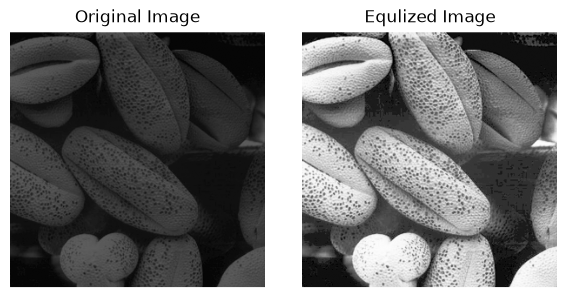

(None, None)

In [ ]:
img5 = cv.imread('images/5.png', cv.IMREAD_GRAYSCALE)
equalized_img5 = histogram_equalization(img5)
plt.figure(figsize=(6, 4))
plt_2(1, 2, 1, img5, 'Original Image', 'gray')
plt_2(1, 2, 2, equalized_img5, 'Equalized Image', 'gray')
plt.tight_layout(), plt.show()

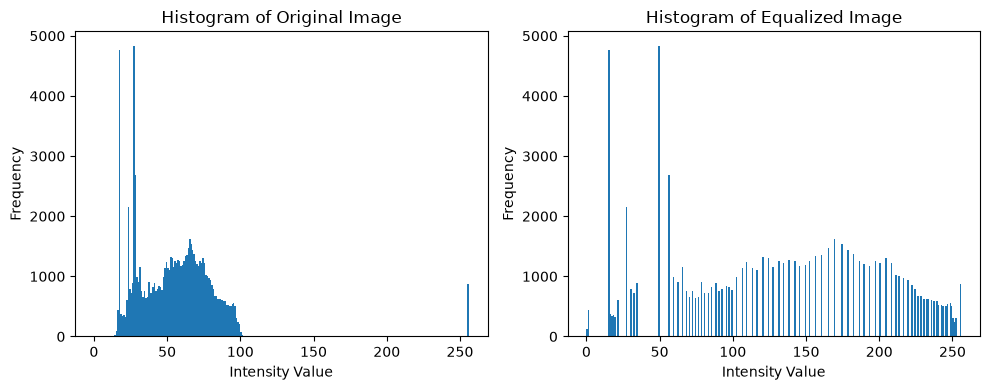

In [ ]:
plt.figure(figsize=(8, 4))
plt_3(1, 2, 1, img5, None, 'Intensity Value', 'Frequency', 'Histogram of Original Image', kind='hist', bins=256, range_=(0, 256))
plt_3(1, 2, 2, equalized_img5, None, 'Intensity Value', 'Frequency', 'Histogram of Equalized Image', kind='hist', bins=256, range_=(0, 256))
plt.tight_layout(), plt.show()

# Question 6 — Histogram Equalization of the Foreground

In this question, histogram equalization is applied only to the
foreground.


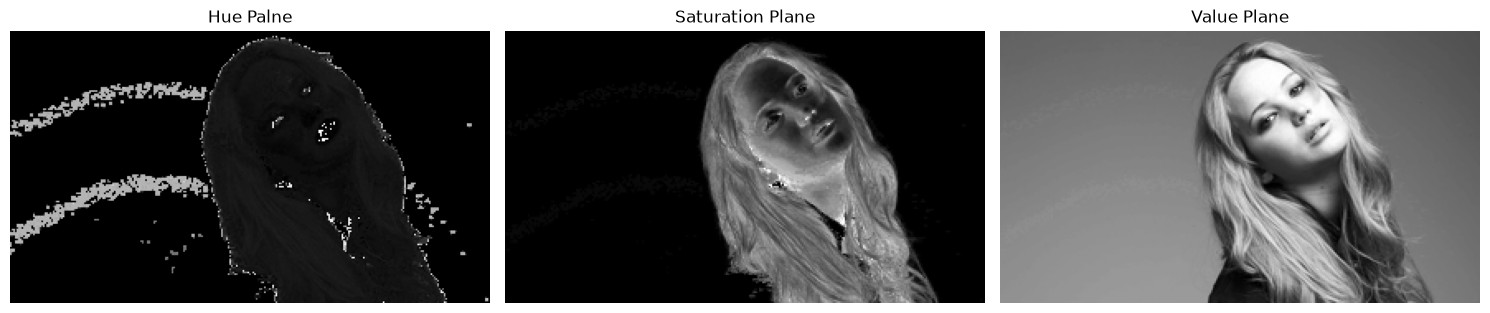

(None, None)

In [ ]:
img6 = cv.imread('images/6.png')
hsv_img6 = cv.cvtColor(img6, cv.COLOR_BGR2HSV)
H6, S6, V6 = cv.split(hsv_img6)
plt.figure(figsize=(15, 4))
plt_2(1, 3, 1, H6, 'Hue Plane', 'gray')
plt_2(1, 3, 2, S6, 'Saturation Plane', 'gray')
plt_2(1, 3, 3, V6, 'Value Plane', 'gray')
plt.tight_layout(), plt.show()

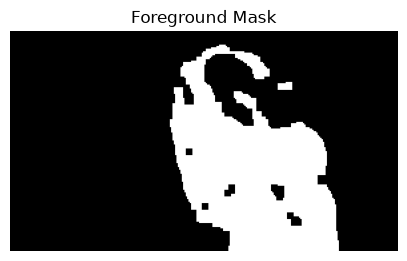

(Text(0.5, 1.0, 'Foreground Mask'),
 (np.float64(-0.5), np.float64(290.5), np.float64(164.5), np.float64(-0.5)),
 None)

In [ ]:
threshold_value = 80
_, mask6 = cv.threshold(S6, threshold_value, 255, cv.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
mask6 = cv.morphologyEx(mask6, cv.MORPH_OPEN, kernel)
mask6 = cv.morphologyEx(mask6, cv.MORPH_CLOSE, kernel)
plt.figure(figsize=(5, 4))
plt_2(1, 1, 1, mask6, 'Foreground Mask', 'gray')
plt.tight_layout(), plt.show()

In [ ]:
foreground6 = cv.bitwise_and(img6, img6, mask=mask6)
gray6 = cv.cvtColor(foreground6, cv.COLOR_BGR2GRAY)
foreground_pixels = gray6[mask6 > 0]
hist6 = np.bincount(foreground_pixels, minlength=256)
cdf6 = np.cumsum(hist6)
nonzero = cdf6[cdf6 > 0]
if len(nonzero) == 0:
    raise ValueError("No foreground pixels were detected. Adjust the threshold.")
cdf_min = nonzero[0]
total_foreground_pixels = foreground_pixels.size
denominator = total_foreground_pixels - cdf_min
if denominator == 0:
    lut6 = np.arange(256, dtype=np.uint8)
else:
    lut6 = ((cdf6 - cdf_min) / denominator * 255)
    lut6 = np.clip(lut6, 0, 255).astype(np.uint8)
equalized_foreground_gray = np.zeros_like(gray6)
equalized_foreground_gray[mask6 > 0] = lut6[gray6[mask6 > 0]]
background_mask6 = cv.bitwise_not(mask6)
background6 = cv.bitwise_and(img6, img6, mask=background_mask6)
equalized_foreground6 = cv.cvtColor(equalized_foreground_gray, cv.COLOR_GRAY2BGR)
result6 = background6.copy()
result6[mask6 > 0] = equalized_foreground6[mask6 > 0]

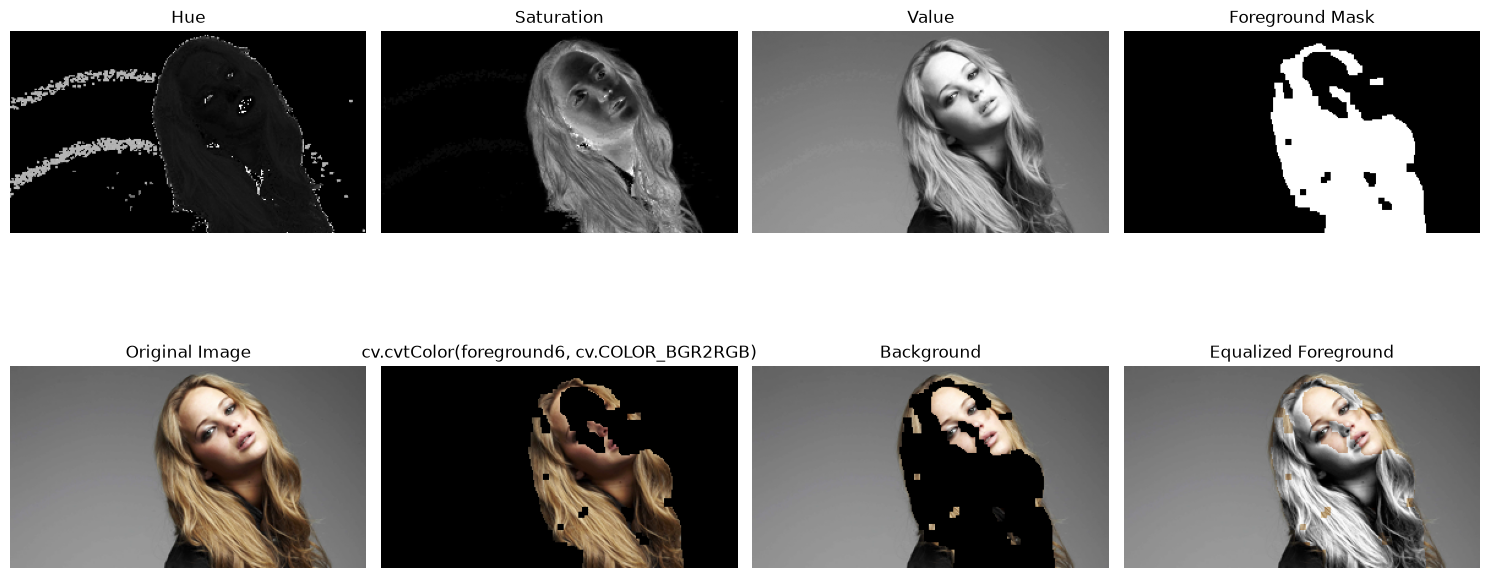

((np.float64(-0.5), np.float64(290.5), np.float64(164.5), np.float64(-0.5)),
 None,
 None)

In [ ]:
plt.figure(figsize=(15, 8))
plt_2(2, 4, 1, H6, 'Hue', 'gray')
plt_2(2, 4, 2, S6, 'Saturation', 'gray')
plt_2(2, 4, 3, V6, 'Value', 'gray')
plt_2(2, 4, 4, mask6, 'Foreground Mask', 'gray')
plt_2(2, 4, 5, cv.cvtColor(img6, cv.COLOR_BGR2RGB), 'Original Image')
plt_2(2, 4, 6, cv.cvtColor(foreground6, cv.COLOR_BGR2RGB), 'Foreground')
plt_2(2, 4, 7, cv.cvtColor(background6, cv.COLOR_BGR2RGB), 'Background')
plt_2(2, 4, 8, cv.cvtColor(result6, cv.COLOR_BGR2RGB), 'Equalized Foreground')
plt.tight_layout(), plt.show()

# Question 7 — Sobel Filtering

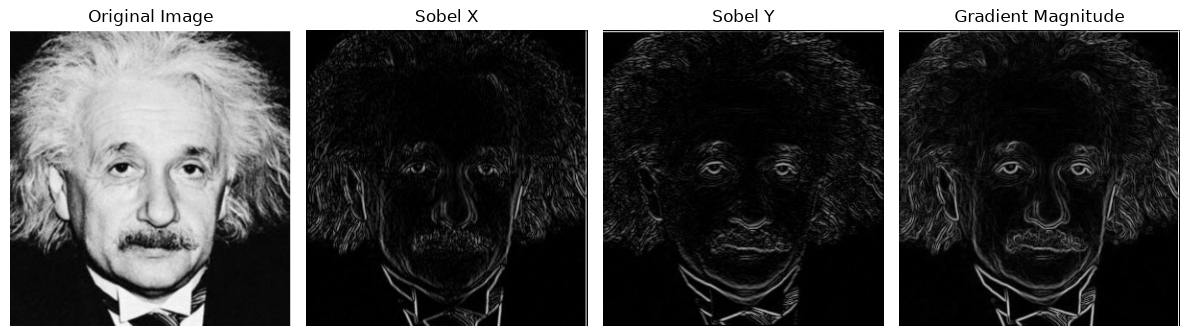

(None, None)

In [ ]:
img7 = cv.imread('images/7.png', cv.IMREAD_GRAYSCALE)
sobel_x_kernel = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]], dtype=np.float32)
sobel_y_kernel = np.array([[-1, -2, -1],
                            [ 0,  0,  0],
                            [ 1,  2,  1]], dtype=np.float32)
gx = cv.filter2D(img7, cv.CV_32F, sobel_x_kernel)
gy = cv.filter2D(img7, cv.CV_32F, sobel_y_kernel)
magnitude = np.sqrt(gx**2 + gy**2)
magnitude = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(12, 4))
plt_2(1, 4, 1, img7, 'Original Image', 'gray')
plt_2(1, 4, 2, cv.convertScaleAbs(gx), 'Sobel X', 'gray')
plt_2(1, 4, 3, cv.convertScaleAbs(gy), 'Sobel Y', 'gray')
plt_2(1, 4, 4, magnitude, 'Gradient Magnitude', 'gray')
plt.tight_layout(), plt.show()

In [ ]:
def filter2D_custom(im, kernel):
    im = im.astype(np.float32)
    kernel = kernel.astype(np.float32)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded_im = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    h, w = im.shape
    result = np.zeros((h, w), dtype=np.float32)
    for i in range(h):
        for j in range(w):
            region = padded_im[i:i + kh, j:j + kw]
            result[i, j] = np.sum(region * kernel)
    return result

In [ ]:
gx_custom = filter2D_custom(img7, sobel_x_kernel)
gy_custom = filter2D_custom(img7, sobel_y_kernel)
magnitude_custom = np.sqrt(gx_custom**2 + gy_custom**2)
magnitude_custom = cv.normalize(magnitude_custom, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(10, 4))
plt_2(1, 2, 1, magnitude, 'OpenCV Sobel Magnitude', 'gray')
plt_2(1, 2, 2, magnitude_custom, 'Custom Sobel Magnitude', 'gray')
plt.tight_layout(), plt.show()

In [ ]:
sobel_mse = np.mean((magnitude.astype(np.float32) - magnitude_custom.astype(np.float32)) ** 2)
print(f"MSE between OpenCV and custom Sobel magnitude: {sobel_mse:.6f}")

## 7(c) Separable Sobel Filtering

In [ ]:
smooth_vertical = np.array([[1], [2], [1]], dtype=np.float32)
derivative_horizontal = np.array([[1, 0, -1]], dtype=np.float32)
temp_x = cv.filter2D(img7, cv.CV_32F, smooth_vertical)
gx_separable = cv.filter2D(temp_x, cv.CV_32F, derivative_horizontal)
smooth_horizontal = np.array([[1, 2, 1]], dtype=np.float32)
derivative_vertical = np.array([[1], [0], [-1]], dtype=np.float32)
temp_y = cv.filter2D(img7, cv.CV_32F, smooth_horizontal)
gy_separable = cv.filter2D(temp_y, cv.CV_32F, derivative_vertical)
magnitude_separable = np.sqrt(gx_separable**2 + gy_separable**2)
magnitude_separable = cv.normalize(magnitude_separable, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(12, 4))
plt_2(1, 3, 1, magnitude, '2-D Sobel Magnitude', 'gray')
plt_2(1, 3, 2, magnitude_custom, 'Custom 2-D Magnitude', 'gray')
plt_2(1, 3, 3, magnitude_separable, 'Separable Sobel Magnitude', 'gray')
plt.tight_layout(), plt.show()

# Question 8 — Intensity Transformation

In [ ]:
def zoom_nearest(im, s):
    if not (0 < s <= 10): raise ValueError("Scale s must satisfy 0 < s <= 10")
    h, w = im.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))
    y_idx = np.minimum((np.arange(new_h) / s).astype(int), h - 1)
    x_idx = np.minimum((np.arange(new_w) / s).astype(int), w - 1)
    return im[y_idx[:, None], x_idx[None, :]]

def zoom_bilinear(im, s):
    if not (0 < s <= 10): raise ValueError("Scale s must satisfy 0 < s <= 10")
    if im.ndim != 2: raise ValueError("zoom_bilinear expects a grayscale image")
    h, w = im.shape
    new_h, new_w = int(round(h * s)), int(round(w * s))
    output = np.zeros((new_h, new_w), dtype=np.float32)
    for y in range(new_h):
        src_y = y / s
        y0 = min(int(np.floor(src_y)), h - 1)
        y1 = min(y0 + 1, h - 1)
        dy = src_y - y0
        for x in range(new_w):
            src_x = x / s
            x0 = min(int(np.floor(src_x)), w - 1)
            x1 = min(x0 + 1, w - 1)
            dx = src_x - x0
            top = (1 - dx) * im[y0, x0] + dx * im[y0, x1]
            bottom = (1 - dx) * im[y1, x0] + dx * im[y1, x1]
            output[y, x] = (1 - dy) * top + dy * bottom
    return np.clip(output, 0, 255).astype(im.dtype)

def normalized_ssd(original, reconstructed):
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)
    return np.mean((original - reconstructed) ** 2) / (255.0 ** 2)

In [ ]:
scale = 4
zoom_results = []
for number in (1, 2):
    small_path = f'images/im0{number}small.png'
    large_path = f'images/im0{number}.png'
    small = cv.imread(small_path, cv.IMREAD_GRAYSCALE)
    large = cv.imread(large_path, cv.IMREAD_GRAYSCALE)
    if small is None or large is None:
        print(f"Skipping pair {number}: check {small_path} and {large_path}")
        continue
    nearest = zoom_nearest(small, scale)
    bilinear = zoom_bilinear(small, scale)
    if nearest.shape != large.shape:
        nearest = cv.resize(nearest, (large.shape[1], large.shape[0]), interpolation=cv.INTER_NEAREST)
    if bilinear.shape != large.shape:
        bilinear = cv.resize(bilinear, (large.shape[1], large.shape[0]), interpolation=cv.INTER_LINEAR)
    ssd_nearest = normalized_ssd(large, nearest)
    ssd_bilinear = normalized_ssd(large, bilinear)
    zoom_results.append((number, large, nearest, bilinear, ssd_nearest, ssd_bilinear))
    print(f"Image pair {number}: nearest SSD = {ssd_nearest:.6f}, bilinear SSD = {ssd_bilinear:.6f}")

Nearest-neighbor normalized SSD 0.0021101048
Bilinear normalized SSD 0.0030980303


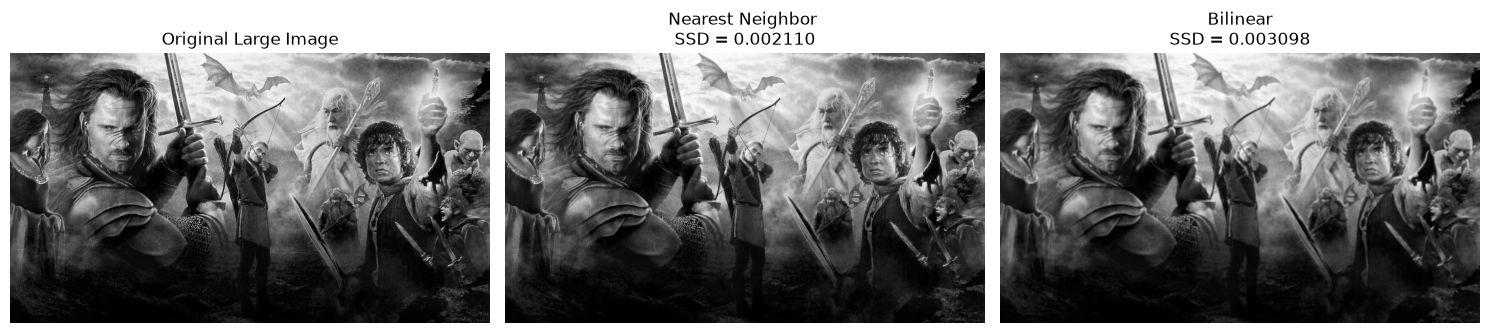

In [ ]:
for number, large, nearest, bilinear, ssd_nearest, ssd_bilinear in zoom_results:
    plt.figure(figsize=(15, 4))
    plt_2(1, 3, 1, large, f'Original Large Image {number}', 'gray')
    plt_2(1, 3, 2, nearest, f'Nearest Neighbor\nSSD = {ssd_nearest:.6f}', 'gray')
    plt_2(1, 3, 3, bilinear, f'Bilinear\nSSD = {ssd_bilinear:.6f}', 'gray')
    plt.tight_layout(), plt.show()

# Question 9 — GrabCut Segmentation

In [ ]:
img9 = cv.imread(r"images\WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg")
h, w = img9.shape[:2]
mask9 = np.zeros((h, w), np.uint8)
bgModel = np.zeros((1, 65), np.float64)
fgModel = np.zeros((1, 65), np.float64)
rect = (int(w * 0.10), int(h * 0.05), int(w * 0.80), int(h * 0.85))
cv.grabCut(img9, mask9, rect, bgModel, fgModel, 5, cv.GC_INIT_WITH_RECT)
binary_mask9 = np.where((mask9 == cv.GC_FGD) | (mask9 == cv.GC_PR_FGD), 255, 0).astype(np.uint8)
foreground9 = cv.bitwise_and(img9, img9, mask=binary_mask9)
background_mask9 = cv.bitwise_not(binary_mask9)
background9 = cv.bitwise_and(img9, img9, mask=background_mask9)

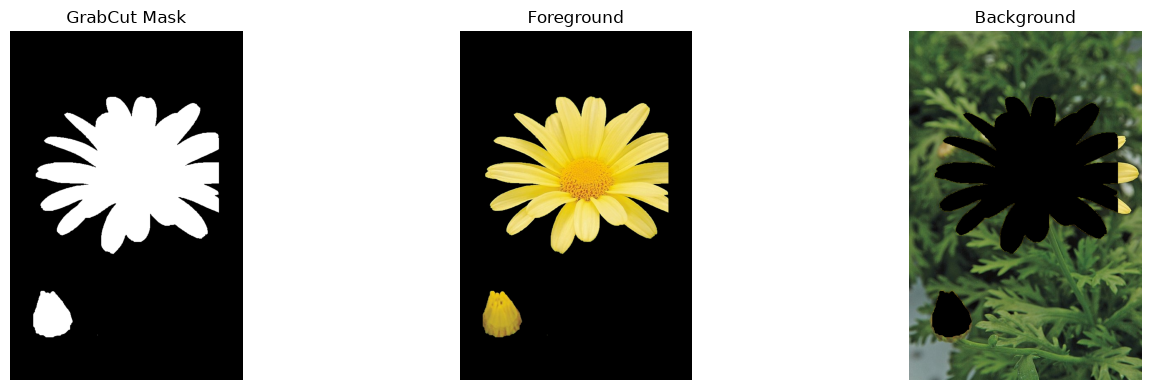

In [ ]:
plt.figure(figsize=(15, 4))
plt_2(1, 3, 1, binary_mask9, 'GrabCut Mask', 'gray')
plt_2(1, 3, 2, cv.cvtColor(foreground9, cv.COLOR_BGR2RGB), 'Foreground')
plt_2(1, 3, 3, cv.cvtColor(background9, cv.COLOR_BGR2RGB), 'Background')
plt.tight_layout(), plt.show()

In [ ]:
blurred_background9 = cv.GaussianBlur(img9, (51, 51), 0)
enhanced9 = np.where(binary_mask9[:, :, None] == 255, img9, blurred_background9)
enhanced9 = enhanced9.astype(np.uint8)

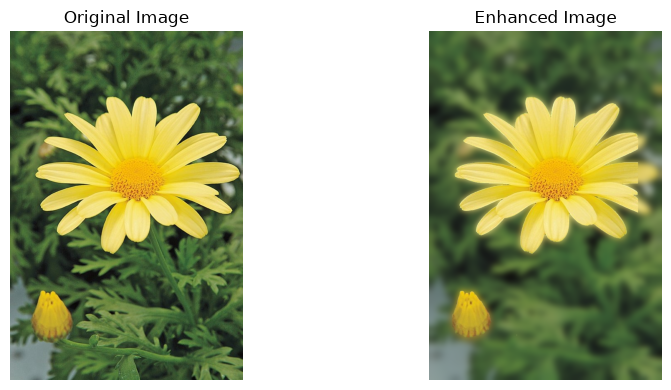

In [ ]:
plt.figure(figsize=(10, 4))
plt_2(1, 2, 1, cv.cvtColor(img9, cv.COLOR_BGR2RGB), 'Original Image')
plt_2(1, 2, 2, cv.cvtColor(enhanced9, cv.COLOR_BGR2RGB), 'Enhanced Image')
plt.tight_layout(), plt.show()

## Why is the background just beyond the flower edge dark?

The dark region occurs because the GrabCut segmentation mask does not
perfectly follow the boundary of the flower.

Some pixels immediately outside the flower may be classified as
background. These pixels are replaced by the blurred background.

Since the surrounding background contains dark regions, Gaussian
blurring spreads the intensity of these regions around the boundary.

Therefore, the dark area is mainly caused by segmentation boundary
errors combined with strong background blurring.

# Question 10 — Intensity Transformation

In [ ]:
img10 = cv.imread(r"images\WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg")
bilateral10 = cv.bilateralFilter(img10, d=9, sigmaColor=75, sigmaSpace=75)
gaussian10 = cv.GaussianBlur(img10, (9, 9), 75)

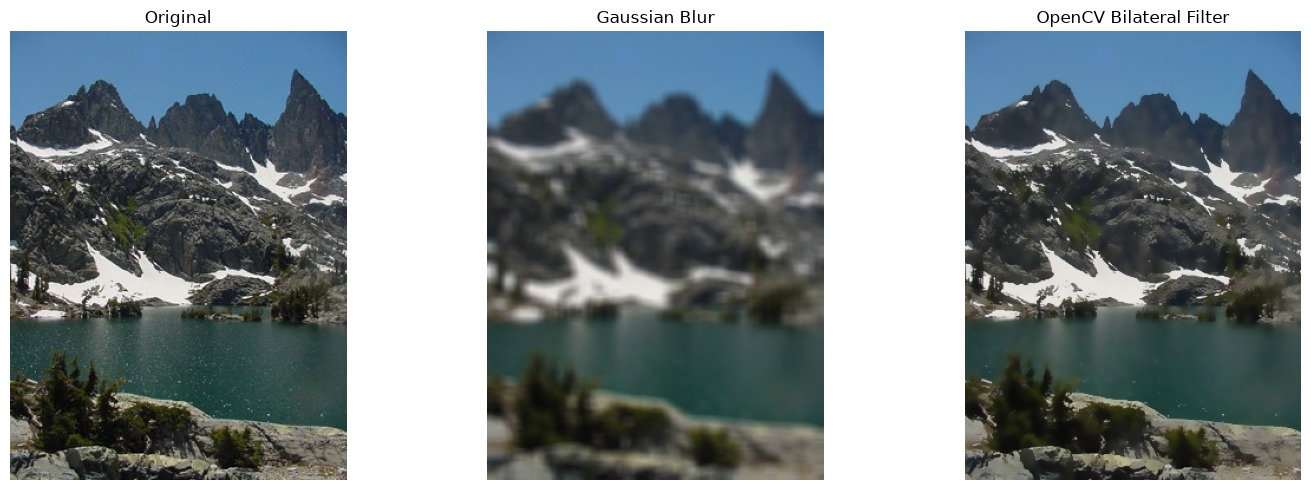

In [ ]:
plt.figure(figsize=(15, 4))
plt_2(1, 3, 1, cv.cvtColor(img10, cv.COLOR_BGR2RGB), 'Original Image')
plt_2(1, 3, 2, cv.cvtColor(gaussian10, cv.COLOR_BGR2RGB), 'Gaussian Blur')
plt_2(1, 3, 3, cv.cvtColor(bilateral10, cv.COLOR_BGR2RGB), 'OpenCV Bilateral Filter')
plt.tight_layout(), plt.show()

## 10(b) Own Bilateral Filter

In [ ]:
def bilateral_filter_gray(image, kernel_size=5, sigma_space=10, sigma_range=30):
    image = image.astype(np.float32)
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode="reflect")
    h, w = image.shape
    output = np.zeros_like(image)
    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_weights = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma_space ** 2))
    for i in range(h):
        for j in range(w):
            region = padded[i:i + kernel_size, j:j + kernel_size]
            center = image[i, j]
            range_weights = np.exp(-((region - center) ** 2) / (2 * sigma_range ** 2))
            weights = (spatial_weights * range_weights)
            weighted_sum = np.sum(weights * region)
            weight_sum = np.sum(weights)
            output[i, j] = (weighted_sum / weight_sum)
    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
gray10 = cv.cvtColor(img10, cv.COLOR_BGR2GRAY)
opencv_bilateral_gray = cv.bilateralFilter(gray10, d=5, sigmaColor=30, sigmaSpace=10)
my_bilateral_gray = bilateral_filter_gray(gray10, kernel_size=5, sigma_space=10, sigma_range=30)

plt.figure(figsize=(15, 4))
plt_2(1, 3, 1, gray10, 'Original Grayscale', 'gray')
plt_2(1, 3, 2, opencv_bilateral_gray, 'OpenCV Bilateral', 'gray')
plt_2(1, 3, 3, my_bilateral_gray, 'Custom Bilateral Filter', 'gray')
plt.tight_layout(), plt.show()

## Quantitative Comparison

Mean Squared Error (MSE) is used to compare the manually implemented
bilateral filter with OpenCV's bilateral filter.

A smaller MSE indicates that the manually implemented result is closer
to OpenCV's result.

In [ ]:
mse10 = np.mean((opencv_bilateral_gray.astype(np.float32) - my_bilateral_gray.astype(np.float32)) ** 2)
print("MSE between OpenCV and my bilateral filter:", mse10)
if mse10 == 0: psnr10 = float("inf")
else: psnr10 = 10 * np.log10((255 ** 2) / mse10)
print("PSNR:", psnr10, "dB")

MSE between OpenCV and my bilateral filter: 5.617387
PSNR: 40.63546 dB
